<a href="https://colab.research.google.com/github/EnasF/Applying-XAI-for-Demand-Forecasting-and-Pricing-Decision-in-Supply-Chain/blob/main/Capstone_Project__TCN_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TCN Demand Forecasting Across Three Samples

This notebook trains and evaluates a Temporal Convolutional Network (TCN) on three samples: **Sample A**, **Sample B**, and **Sample C**.

The workflow includes:

1. Loading the three processed datasets.
2. Encoding categorical features.
3. Creating grouped 28-day sliding windows by `store_id` and `item_id`.
4. Training a separate TCN model for each sample.
5. Evaluating RMSE, MAE, and R².
6. Comparing results across samples.

## 1. Import Libraries


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, Dropout, Add, Activation, Dense, LayerNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# SHAP explainability
!pip install shap -q
import shap

plt.style.use("ggplot")

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

## 2. Mount Google Drive and Load Datasets

Update the file paths if your files are stored in a different folder.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Load three processed samples
df_A = pd.read_csv(
    '/content/drive/MyDrive/Graduation Project Data/processed_data_A.csv',
    parse_dates=["date"]
)

df_B = pd.read_csv(
    '/content/drive/MyDrive/Graduation Project Data/processed_data_B.csv',
    parse_dates=["date"]
)

df_C = pd.read_csv(
    '/content/drive/MyDrive/Graduation Project Data/processed_data_C.csv',
    parse_dates=["date"]
)

print("Sample A shape:", df_A.shape)
print("Sample B shape:", df_B.shape)
print("Sample C shape:", df_C.shape)

Mounted at /content/drive
Sample A shape: (737580, 49)
Sample B shape: (737580, 49)
Sample C shape: (737580, 49)


## 3. Encode Categorical Features


In [ ]:
def encode_categorical_features(df, categorical_cols, drop_original=False):
    """
    Encode categorical columns into integer codes for TCN/LSTM/deep learning models.
    """
    df = df.copy()
    category_mappings = {}

    for col in categorical_cols:
        if col not in df.columns:
            print(f"Warning: {col} not found in dataframe. Skipping.")
            continue

        df[col] = df[col].astype("category")
        category_mappings[col] = dict(enumerate(df[col].cat.categories))
        df[col + "_code"] = df[col].cat.codes

        if drop_original:
            df.drop(columns=[col], inplace=True)

    print("Categorical encoding completed.")
    return df, category_mappings


categorical_cols = [
    'store_id', 'state_id', 'item_id', 'dept_id', 'cat_id',
    'weekday', 'event_name_1', 'event_type_1',
    'event_name_2', 'event_type_2', 'month_year'
]

df_A, mappings_A = encode_categorical_features(df_A, categorical_cols, drop_original=False)
df_B, mappings_B = encode_categorical_features(df_B, categorical_cols, drop_original=False)
df_C, mappings_C = encode_categorical_features(df_C, categorical_cols, drop_original=False)

samples = {
    "Sample_A": df_A,
    "Sample_B": df_B,
    "Sample_C": df_C
}

Categorical encoding completed.
Categorical encoding completed.
Categorical encoding completed.


## 4. Define Features, Target, and Sequence Settings


In [ ]:
feature_cols = [
    'item_id_code', 'dept_id_code', 'cat_id_code', 'store_id_code', 'state_id_code',
    'wm_yr_wk', 'weekday_code', 'wday', 'month', 'year',
    'event_name_1_code', 'event_type_1_code', 'event_name_2_code', 'event_type_2_code',
    'snap_CA', 'snap_TX', 'snap_WI',
    'sell_price', 'month_year_code',
    'CAUR', 'CPIAUCSL', 'CPIUFDSL','FEDFUNDS_diff2',
    'TXUR', 'UNRATE', 'UMCSENT_diff', 'WIUR',
    'demand_lag_7', 'demand_lag_14', 'demand_lag_28',
    'demand_rolling_mean_7', 'demand_rolling_std_7',
    'demand_rolling_mean_14', 'demand_rolling_std_14',
    'demand_rolling_mean_28', 'demand_rolling_std_28',
    'price_lag_1', 'price_lag_7',
    'price_rolling_mean_7', 'price_rolling_std_7',
    'price_rolling_mean_28', 'price_rolling_std_28',
    'sell_price_normalized', 'price_change_flag', 'price_change_direction'
]

target_col = 'demand'
SEQ_LEN = 28
group_cols = ["store_id", "item_id"]

'''# Check missing feature columns before training
for sample_name, df_sample in samples.items():
    missing_cols = [col for col in feature_cols + [target_col, 'date'] + group_cols if col not in df_sample.columns]
    if missing_cols:
        print(f"{sample_name} missing columns:", missing_cols)
    else:
        print(f"{sample_name}: all required columns available.")'''

'# Check missing feature columns before training\nfor sample_name, df_sample in samples.items():\n    missing_cols = [col for col in feature_cols + [target_col, \'date\'] + group_cols if col not in df_sample.columns]\n    if missing_cols:\n        print(f"{sample_name} missing columns:", missing_cols)\n    else:\n        print(f"{sample_name}: all required columns available.")'

## 5. Create Grouped Sliding-Window Sequences

The model uses the previous 28 time steps to predict the next demand value. Windows are created separately for each `store_id` and `item_id` to avoid mixing different product-store time series.


In [ ]:
def create_grouped_sequences(df, feature_cols, target_col, seq_len, group_cols):
    X_seq = []
    y_seq = []

    for _, group in df.groupby(group_cols):
        group = group.sort_values("date")

        X_group = group[feature_cols].values
        y_group = group[target_col].values.reshape(-1, 1)

        if len(group) <= seq_len:
            continue

        for i in range(seq_len, len(group)):
            X_seq.append(X_group[i-seq_len:i])
            y_seq.append(y_group[i])

    return np.array(X_seq), np.array(y_seq)

## 6. Define the TCN Model


In [ ]:
def residual_block(x, filters, kernel_size, dilation_rate, dropout_rate):
    shortcut = x

    x = Conv1D(
        filters=filters,
        kernel_size=kernel_size,
        padding='causal',
        dilation_rate=dilation_rate
    )(x)
    x = LayerNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(dropout_rate)(x)

    x = Conv1D(
        filters=filters,
        kernel_size=kernel_size,
        padding='causal',
        dilation_rate=dilation_rate
    )(x)
    x = LayerNormalization()(x)

    if shortcut.shape[-1] != filters:
        shortcut = Conv1D(filters=filters, kernel_size=1, padding='same')(shortcut)

    x = Add()([shortcut, x])
    x = Activation('relu')(x)
    return x


def build_tcn(input_shape):
    inputs = Input(shape=input_shape)
    x = inputs

    for dilation_rate in [1, 2, 4, 8, 16]:
        x = residual_block(
            x,
            filters=64,
            kernel_size=3,
            dilation_rate=dilation_rate,
            dropout_rate=0.2
        )

    # Use the last time-step representation
    x = x[:, -1, :]
    x = Dense(32, activation='relu')(x)
    output = Dense(1)(x)

    model = Model(inputs, output)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    return model

## 7. Train and Evaluate TCN on One Sample

This function prepares one sample, trains a new TCN model, evaluates it, and returns the metrics plus arrays needed for SHAP and PDP analysis.


In [ ]:
def train_tcn_on_sample(df, sample_name):
    print("===============================")
    print(f"Running TCN for {sample_name}")
    print("===============================")

    df = df.copy()

    required_cols = feature_cols + [target_col, "date"] + group_cols
    df = df.dropna(subset=required_cols)
    df = df.sort_values(group_cols + ["date"]).reset_index(drop=True)

    # Create grouped sliding windows before scaling
    X_raw, y_raw = create_grouped_sequences(
        df=df,
        feature_cols=feature_cols,
        target_col=target_col,
        seq_len=SEQ_LEN,
        group_cols=group_cols
    )

    print("Raw X shape:", X_raw.shape)
    print("Raw y shape:", y_raw.shape)

    if len(X_raw) == 0:
        raise ValueError(f"No sequences created for {sample_name}. Check group columns and sequence length.")

    # Scale X after sequence creation
    n_samples, seq_len, n_features = X_raw.shape
    X_2d = X_raw.reshape(-1, n_features)

    x_scaler = MinMaxScaler()
    y_scaler = MinMaxScaler()

    X_scaled_2d = x_scaler.fit_transform(X_2d)
    X = X_scaled_2d.reshape(n_samples, seq_len, n_features)
    y = y_scaler.fit_transform(y_raw)

    print("Scaled X shape:", X.shape)
    print("Scaled y shape:", y.shape)

    # Time-based split
    train_size = int(len(X) * 0.7)
    val_size = int(len(X) * 0.2)

    X_train = X[:train_size]
    y_train = y[:train_size]

    X_val = X[train_size:train_size + val_size]
    y_val = y[train_size:train_size + val_size]

    X_test = X[train_size + val_size:]
    y_test = y[train_size + val_size:]

    print("Train:", X_train.shape)
    print("Validation:", X_val.shape)
    print("Test:", X_test.shape)

    model = build_tcn(input_shape=(X_train.shape[1], X_train.shape[2]))

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=20,
        restore_best_weights=True
    )

    reduce_lr = ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=10,
        min_lr=1e-6
    )

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=100,
        batch_size=64,
        callbacks=[early_stop, reduce_lr],
        verbose=1
    )

    # Prediction
    y_pred_scaled = model.predict(X_test)
    y_pred = y_scaler.inverse_transform(y_pred_scaled)
    y_true = y_scaler.inverse_transform(y_test)

    # Evaluation
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"{sample_name} TCN Results")
    print("RMSE:", rmse)
    print("MAE:", mae)
    print("R2:", r2)

    # Loss plot
    plt.figure(figsize=(10, 5))
    plt.plot(history.history["loss"], label="Training Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(f"{sample_name} - Training and Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    # Actual vs predicted plot
    plt.figure(figsize=(12, 5))
    plt.plot(y_true[:200], label="Actual Demand")
    plt.plot(y_pred[:200], label="Predicted Demand")
    plt.title(f"{sample_name} - Actual vs Predicted Demand")
    plt.xlabel("Time")
    plt.ylabel("Demand")
    plt.legend()
    plt.show()

    return {
        "Sample": sample_name,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "model": model,
        "history": history,
        "x_scaler": x_scaler,
        "y_scaler": y_scaler,
        "X_train": X_train,
        "X_val": X_val,
        "X_test": X_test,
        "y_train": y_train,
        "y_val": y_val,
        "train_size": train_size,
        "val_size": val_size,
        "y_test": y_test,
        "y_true": y_true,
        "y_pred": y_pred
    }

## 8. Run TCN on All Three Samples


Running TCN for Sample_A


/tmp/ipykernel_4556/1599321993.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, group in df.groupby(group_cols):


Raw X shape: (726940, 28, 45)
Raw y shape: (726940, 1)
Scaled X shape: (726940, 28, 45)
Scaled y shape: (726940, 1)
Train: (508857, 28, 45)
Validation: (145388, 28, 45)
Test: (72695, 28, 45)
Epoch 1/100
7951/7951 ━━━━━━━━━━━━━━━━━━━━ 69s 6ms/step - loss: 0.0062 - mae: 0.0203 - val_loss: 1.3672e-04 - val_mae: 0.0069 - learning_rate: 0.0010
Epoch 2/100
7951/7951 ━━━━━━━━━━━━━━━━━━━━ 37s 5ms/step - loss: 1.5285e-04 - mae: 0.0069 - val_loss: 9.3022e-05 - val_mae: 0.0041 - learning_rate: 0.0010
Epoch 3/100
7951/7951 ━━━━━━━━━━━━━━━━━━━━ 37s 5ms/step - loss: 1.2178e-04 - mae: 0.0054 - val_loss: 1.1170e-04 - val_mae: 0.0063 - learning_rate: 0.0010
Epoch 4/100
7951/7951 ━━━━━━━━━━━━━━━━━━━━ 37s 5ms/step - loss: 1.1283e-04 - mae: 0.0048 - val_loss: 9.0874e-05 - val_mae: 0.0045 - learning_rate: 0.0010
Epoch 5/100
7951/7951 ━━━━━━━━━━━━━━━━━━━━ 37s 5ms/step - loss: 1.0868e-04 - mae: 0.0046 - val_loss: 9.2800e-05 - val_mae: 0.0040 - learning_rate: 0.0010
Epoch 6/100
7951/7951 ━━━━━━━━━━━━━━━━━━━━ 

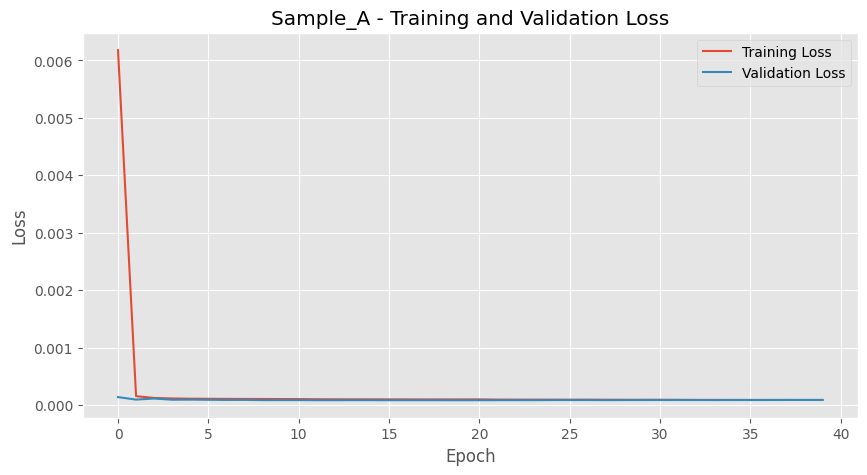

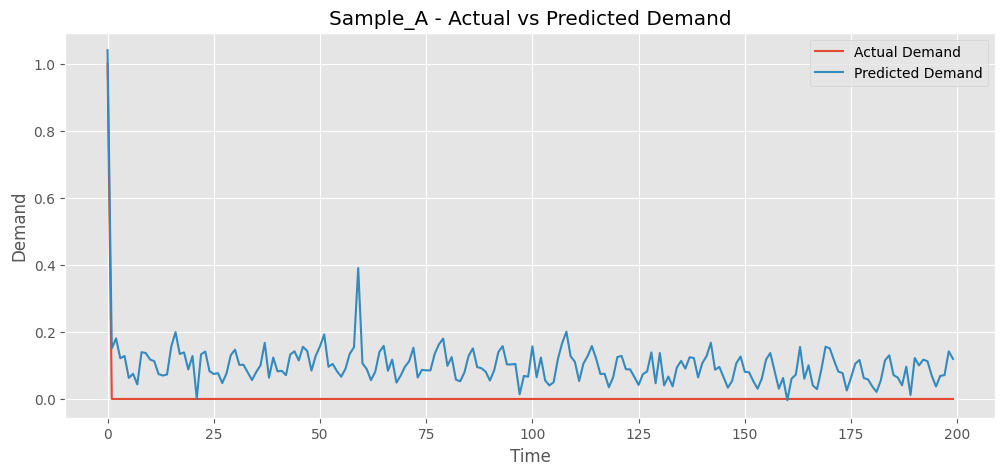

In [ ]:
result_A = train_tcn_on_sample(df_A, "Sample_A")


Running TCN for Sample_B


/tmp/ipykernel_4556/1599321993.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, group in df.groupby(group_cols):


Raw X shape: (726940, 28, 45)
Raw y shape: (726940, 1)
Scaled X shape: (726940, 28, 45)
Scaled y shape: (726940, 1)
Train: (508857, 28, 45)
Validation: (145388, 28, 45)
Test: (72695, 28, 45)
Epoch 1/100
7951/7951 ━━━━━━━━━━━━━━━━━━━━ 65s 6ms/step - loss: 0.0021 - mae: 0.0184 - val_loss: 1.3454e-04 - val_mae: 0.0055 - learning_rate: 0.0010
Epoch 2/100
7951/7951 ━━━━━━━━━━━━━━━━━━━━ 38s 5ms/step - loss: 2.3510e-04 - mae: 0.0087 - val_loss: 1.2864e-04 - val_mae: 0.0053 - learning_rate: 0.0010
Epoch 3/100
7951/7951 ━━━━━━━━━━━━━━━━━━━━ 38s 5ms/step - loss: 2.0402e-04 - mae: 0.0073 - val_loss: 1.4069e-04 - val_mae: 0.0060 - learning_rate: 0.0010
Epoch 4/100
7951/7951 ━━━━━━━━━━━━━━━━━━━━ 38s 5ms/step - loss: 1.9442e-04 - mae: 0.0067 - val_loss: 1.2826e-04 - val_mae: 0.0046 - learning_rate: 0.0010
Epoch 5/100
7951/7951 ━━━━━━━━━━━━━━━━━━━━ 38s 5ms/step - loss: 1.8755e-04 - mae: 0.0063 - val_loss: 1.2823e-04 - val_mae: 0.0049 - learning_rate: 0.0010
Epoch 6/100
7951/7951 ━━━━━━━━━━━━━━━━━━━━ 

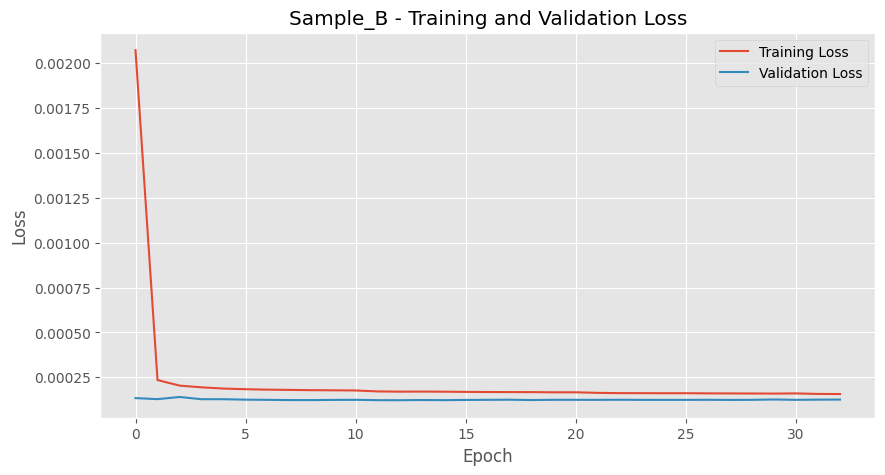

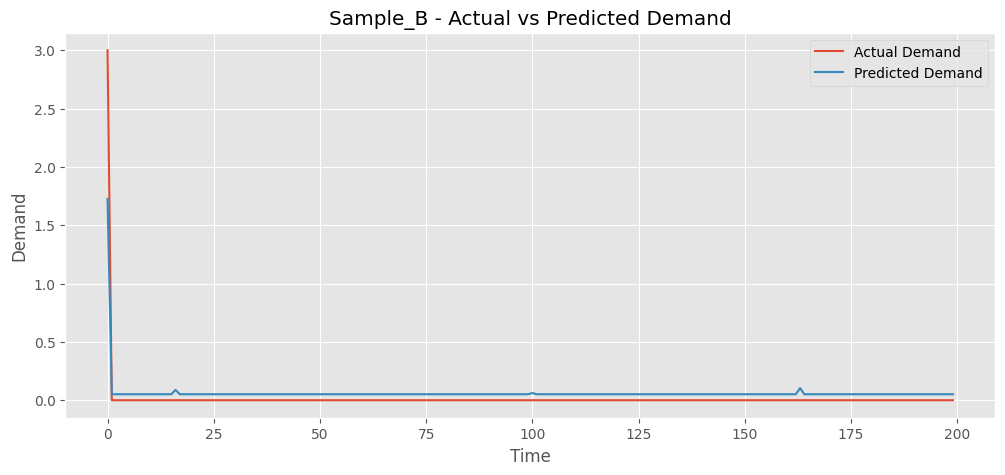

In [ ]:
result_B = train_tcn_on_sample(df_B, "Sample_B")

Running TCN for Sample_C


/tmp/ipykernel_4556/1599321993.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, group in df.groupby(group_cols):


Raw X shape: (726940, 28, 45)
Raw y shape: (726940, 1)
Scaled X shape: (726940, 28, 45)
Scaled y shape: (726940, 1)
Train: (508857, 28, 45)
Validation: (145388, 28, 45)
Test: (72695, 28, 45)
Epoch 1/100
7951/7951 ━━━━━━━━━━━━━━━━━━━━ 65s 6ms/step - loss: 0.0026 - mae: 0.0140 - val_loss: 2.3786e-05 - val_mae: 0.0026 - learning_rate: 0.0010
Epoch 2/100
7951/7951 ━━━━━━━━━━━━━━━━━━━━ 38s 5ms/step - loss: 5.3573e-05 - mae: 0.0044 - val_loss: 2.3864e-05 - val_mae: 0.0026 - learning_rate: 0.0010
Epoch 3/100
7951/7951 ━━━━━━━━━━━━━━━━━━━━ 39s 5ms/step - loss: 4.1475e-05 - mae: 0.0034 - val_loss: 2.3542e-05 - val_mae: 0.0024 - learning_rate: 0.0010
Epoch 4/100
7951/7951 ━━━━━━━━━━━━━━━━━━━━ 38s 5ms/step - loss: 3.9237e-05 - mae: 0.0031 - val_loss: 2.1354e-05 - val_mae: 0.0028 - learning_rate: 0.0010
Epoch 5/100
7951/7951 ━━━━━━━━━━━━━━━━━━━━ 38s 5ms/step - loss: 3.8366e-05 - mae: 0.0030 - val_loss: 2.1459e-05 - val_mae: 0.0026 - learning_rate: 0.0010
Epoch 6/100
7951/7951 ━━━━━━━━━━━━━━━━━━━━ 

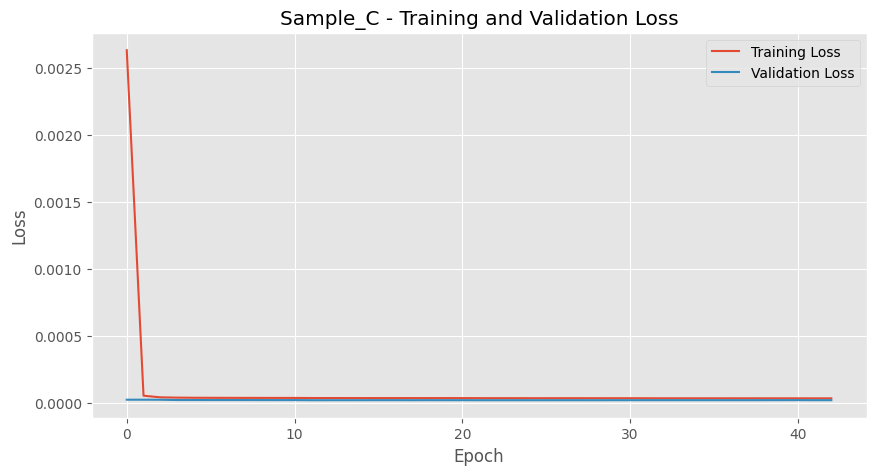

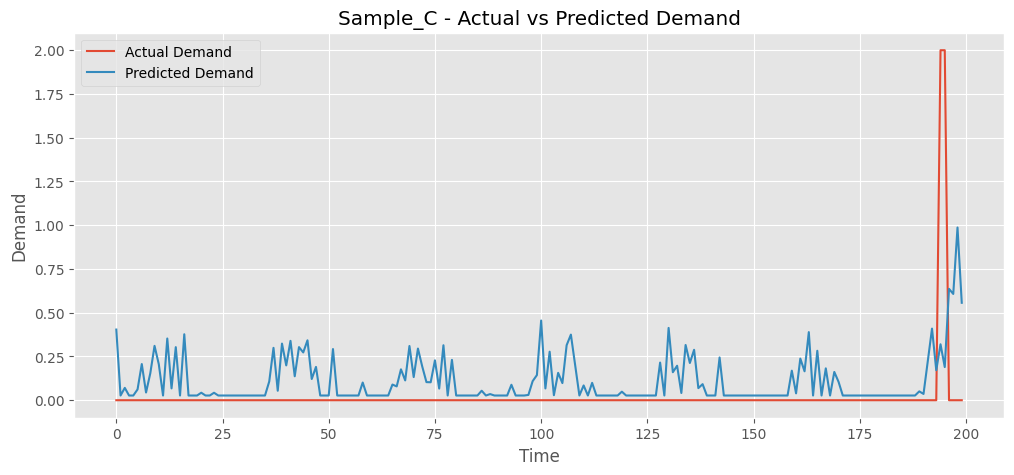

In [ ]:
result_C = train_tcn_on_sample(df_C, "Sample_C")


In [ ]:
results = [result_A, result_B, result_C]

## 9. Compare Model Results Across Samples


In [ ]:
results_df = pd.DataFrame([
    {
        "Sample": r["Sample"],
        "RMSE": r["RMSE"],
        "MAE": r["MAE"],
        "R2": r["R2"]
    }
    for r in results
])

print("Final TCN Comparison Across Three Samples")
display(results_df)

Final TCN Comparison Across Three Samples


,Sample,RMSE,MAE,R2
0,Sample_A,2.228140,0.991166,0.531224
1,Sample_B,1.735585,0.808170,0.681915
2,Sample_C,1.826944,0.822777,0.709604
